In [1]:
import geopandas as gpd
import pandas as pd
from shapely.ops import transform
import matplotlib.pyplot as plt
import numpy as np
import shapely
from shapely.geometry import Polygon
import pyvista as pv
import os
import cv2

/opt/anaconda3/envs/streamliten/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
import os
import geopandas as gpd

# Rotterdam footprints
PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"
rotterdam_footprints_path = os.path.join(PROJECT_ROOT, "data/oblique_images/rotterdam_footprints_renamed.geojson")

gdf_image_footprints = gpd.read_file(rotterdam_footprints_path)
gdf_image_footprints = gdf_image_footprints.set_crs("EPSG:7415", allow_override=True)
gdf_image_footprints.columns = gdf_image_footprints.columns.str.strip()

# Check and update columns
if 'Focal Length Input' in gdf_image_footprints.columns:
    # 1. Rename 'Focal Length Input' to 'fx'
    gdf_image_footprints = gdf_image_footprints.rename(columns={'Focal Length Input': 'fx'})
    
    # 2. Create duplicate column 'fy'
    gdf_image_footprints['fy'] = gdf_image_footprints['fx']

# 3. Save the changes back to the GeoJSON file
gdf_image_footprints.to_file(rotterdam_footprints_path, driver="GeoJSON")

print("Updated columns:")
print(gdf_image_footprints.columns)
print(f"Successfully saved changes back to {rotterdam_footprints_path}")

Updated columns:
Index(['id', 'ULx', 'ULy', 'URx', 'URy', 'LLx', 'LLy', 'LRx', 'LRy', 'GSD',
       'ShotOrient', 'Inpho_11', 'Inpho_12', 'Inpho_13', 'Inpho_21',
       'Inpho_22', 'Inpho_23', 'Inpho_31', 'Inpho_32', 'Inpho_33', 'Matrix_11',
       'Matrix_12', 'Matrix_13', 'Matrix_21', 'Matrix_22', 'Matrix_23',
       'Matrix_31', 'Matrix_32', 'Matrix_33', 'CAM', 'Collection Input',
       'image_id', 'Mean median error Calculated', 'Focal Length Calculated',
       'fx', 'Pixel Size Input', 'Median Error Calculated',
       'PPoint X Calculated', 'cx', 'PPoint Y Calculated', 'cy',
       'K1 Calculated', 'K1 Input', 'K2 Calculated', 'K2 Input',
       'K3 Calculated', 'K3 Input', 'P1 Calculated', 'P1 Input',
       'P2 Calculated', 'P2 Input', 'X Calculated', 'X', 'Y Calculated', 'Y',
       'Altitude Calculated', 'Z', 'Omega Calculated', 'omega',
       'Phi Calculated', 'phi', 'Kappa Calculated', 'kappa', 'Yaw Calculated',
       'Yaw Input', 'Pitch Calculated', 'Pitch Input', 'Rol

In [4]:
import sys

SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(SCRIPT_DIR) if "src" in SCRIPT_DIR else SCRIPT_DIR
sys.path.append(os.path.join(PROJECT_ROOT, "src"))

import data_preprocessing
import perspective_projection
import facade_extraction

# File paths
tiles_dir = os.path.join(PROJECT_ROOT, 'data/3dbag_tiles')
geojson_2d_path = os.path.join(tiles_dir, 'lod22_2d.geojson')
geojson_3d_path = os.path.join(tiles_dir, 'lod22_3d.geojson')

underpasses_dir = os.path.join(PROJECT_ROOT, 'data/underpass_polygons')
underpasses_path = os.path.join(underpasses_dir, 'underpasses_rotterdam.geojson')

rotterdam_sample_dir = os.path.join(PROJECT_ROOT, 'rotterdam_sample')
oblique_image_dirs = [
    os.path.join(rotterdam_sample_dir, 'oblique_right'),
    os.path.join(rotterdam_sample_dir, 'oblique_left'),
    os.path.join(rotterdam_sample_dir, 'oblique_forward'),
    os.path.join(rotterdam_sample_dir, 'oblique_back')
]

image_footprints_path = os.path.join(PROJECT_ROOT, 'data/oblique_images/rotterdam_footprints_renamed.geojson')
camera_parameters_path = os.path.join(PROJECT_ROOT, 'output/rotterdam_camera_parameters.csv')

# Load input tables
df_camera_parameters, gdf_underpass_polygons, gdf_building_2d, gdf_building_3d, gdf_image_footprints = (
    data_preprocessing.load_input_data(
        camera_parameters_path, underpasses_path, geojson_2d_path, geojson_3d_path, image_footprints_path, min_length=2
    )
)

print(f"Loaded Camera Parameters: {len(df_camera_parameters)} rows")
print(f"Camera Parameters Sample Image IDs:\n{df_camera_parameters['image_id'].head().tolist()}\n")

# Process critical walls & visibility
_, gdf_critical_edges = data_preprocessing.find_critical_edges(gdf_underpass_polygons, gdf_building_2d, buf_tol=0.1, simpl_tol=0.2, min_length=2)
gdf_critical_walls = data_preprocessing.find_critical_walls(gdf_critical_edges, None, gdf_building_3d, buf_tol=0.5, extend_length=0)
gdf_image_visibility = data_preprocessing.infere_image_visibility(gdf_image_footprints, gdf_critical_walls, theta=60)

print(f"Total Critical Walls: {len(gdf_critical_walls)}")
print(f"Total Visible Images: {len(gdf_image_visibility)}")

Loaded Camera Parameters: 16245 rows
Camera Parameters Sample Image IDs:
['139001497_0026_01_0061_P00_01.jpg', '139001460_0026_01_0024_P00_01.jpg', '139001477_0026_01_0041_P00_01.jpg', '139000575_0022_01_0017_P00_01.jpg', '139001025_0024_01_0070_P00_01.jpg']

Columns available before groupby: ['image_id', 'geometry', 'camera_x', 'camera_y', 'camera_z', 'index_right', 'wall_id', 'wall_height', 'underpass_id', 'edge_id', 'building_id']
Total Critical Walls: 104
Total Visible Images: 72


In [6]:
# Check unique image IDs and data type in df_camera_parameters
print("df_camera_parameters['image_id'] dtype:", df_camera_parameters['image_id'].dtype)
print("\nFirst 5 camera parameter image IDs:")
print(df_camera_parameters['image_id'].head().tolist())

print("\nTarget image ID being searched:")
print(f"clean_image_id: '{clean_image_id}' (Type: {type(clean_image_id)})")

df_camera_parameters['image_id'] dtype: object

First 5 camera parameter image IDs:
['139001497_0026_01_0061_P00_01.jpg', '139001460_0026_01_0024_P00_01.jpg', '139001477_0026_01_0041_P00_01.jpg', '139000575_0022_01_0017_P00_01.jpg', '139001025_0024_01_0070_P00_01.jpg']

Target image ID being searched:
clean_image_id: '178001098_0036_01_0175_P00_01' (Type: <class 'str'>)


In [34]:
# Juan footprints
PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"
juan_camera_para = os.path.join(PROJECT_ROOT, "data/oblique_images/camera_parameters.txt")
juan_footprint = os.path.join(PROJECT_ROOT, "data/oblique_images/image_footprints.geojson")
df_juan_camera_para = pd.read_csv(juan_camera_para, sep='\t', dtype={'image_id': str})
gdf_juan_footprints = gpd.read_file(juan_footprint)
df_juan_camera_para.columns = df_juan_camera_para.columns.str.strip()
#print(df_juan_camera_para.head(10))
#print(gdf_juan_footprints.head(10))
print(df_juan_camera_para["omega"].head(5))
print(df_juan_camera_para["phi"].head(5))
print(df_juan_camera_para["kappa"].head(5))

0    12.13
1    12.51
2    12.56
3    15.22
4    11.38
Name: omega, dtype: float64
0    43.97
1    43.71
2    43.44
3   -41.53
4    44.05
Name: phi, dtype: float64
0    107.63
1    107.11
2    107.51
3   -112.82
4    105.87
Name: kappa, dtype: float64


In [40]:

'''
check if rotterdam footprint and camera parameters linkage is correct
'''

PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"

camera_parameters_path = os.path.join(
    PROJECT_ROOT,
    "output/rotterdam_camera_parameters.csv")

footprints_path = os.path.join(
    PROJECT_ROOT,
    "data/oblique_images/rotterdam_footprints_renamed.geojson"
)

df_camera = pd.read_csv(
    camera_parameters_path,
    sep=",")
gdf_footprints = gpd.read_file(footprints_path)
print(gdf_footprints.columns)
print(df_camera.columns)


Index(['id', 'ULx', 'ULy', 'URx', 'URy', 'LLx', 'LLy', 'LRx', 'LRy', 'GSD',
       'ShotOrient', 'Inpho_11', 'Inpho_12', 'Inpho_13', 'Inpho_21',
       'Inpho_22', 'Inpho_23', 'Inpho_31', 'Inpho_32', 'Inpho_33', 'Matrix_11',
       'Matrix_12', 'Matrix_13', 'Matrix_21', 'Matrix_22', 'Matrix_23',
       'Matrix_31', 'Matrix_32', 'Matrix_33', 'CAM', 'Collection Input',
       'image_id', 'Mean median error Calculated', 'Focal Length Calculated',
       'Focal Length Input', 'Pixel Size Input', 'Median Error Calculated',
       'PPoint X Calculated', 'cx', 'PPoint Y Calculated', 'cy',
       'K1 Calculated', 'K1 Input', 'K2 Calculated', 'K2 Input',
       'K3 Calculated', 'K3 Input', 'P1 Calculated', 'P1 Input',
       'P2 Calculated', 'P2 Input', 'X Calculated', 'X', 'Y Calculated', 'Y',
       'Altitude Calculated', 'Z', 'Omega Calculated', 'omega',
       'Phi Calculated', 'phi', 'Kappa Calculated', 'kappa', 'Yaw Calculated',
       'Yaw Input', 'Pitch Calculated', 'Pitch Input', 'Roll

In [76]:
import pandas as pd
import geopandas as gpd

footprint_path = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights/data/oblique_images/rotterdam_footprints_renamed.geojson"
camera_path = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights/output/rotterdam_camera_parameters.csv"

gdf_footprint = gpd.read_file(footprint_path)
df_camera = pd.read_csv(camera_path)

# Reverse the extra division by multiplying once
gdf_footprint['fx'] = gdf_footprint['fx'] * gdf_footprint['Pixel Size Input']
gdf_footprint['fy'] = gdf_footprint['fy'] * gdf_footprint['Pixel Size Input']

df_camera['fx'] = df_camera['fx'] * gdf_footprint['Pixel Size Input']
df_camera['fy'] = df_camera['fy'] * gdf_footprint['Pixel Size Input']

# Save corrected files
gdf_footprint.to_file(footprint_path, driver="GeoJSON")
df_camera.to_csv(camera_path, index=False)

print("Values successfully restored!")

Values successfully restored!


In [75]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np

# do not run again so we do not rewrite it
# 1. SETUP PATH
PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"

camera_parameters_path = os.path.join(PROJECT_ROOT, "output/rotterdam_camera_parameters.csv")
footprint_geojson_path = os.path.join(PROJECT_ROOT, "data/oblique_images/rotterdam_footprints_renamed.geojson")

print("Loading datasets...")
# Automatically infer separator (comma vs tab) and strip accidental header whitespace
df_camera_csv = pd.read_csv(camera_parameters_path, sep=None, engine='python')
df_camera_csv.columns = df_camera_csv.columns.str.strip()

gdf_footprint = gpd.read_file(footprint_geojson_path)
gdf_footprint.columns = gdf_footprint.columns.str.strip()

# 2. FX, FY -> divide with pixel size. apply mathematics
print("Applying calculations...")
# Check if necessary columns exist in gdf_footprint
if 'fx' in gdf_footprint.columns and 'Pixel Size Input' in gdf_footprint.columns:
    # Compute focal length in pixels from gdf_footprint
    # .values avoids index mismatch issues between the GeoDataFrame and DataFrame
    focal_length_px = (gdf_footprint['fx'] / gdf_footprint['Pixel Size Input']).values
    # Assign/Update both 'fx' and 'fy' in df_camera_csv
    df_camera_csv['fx'] = focal_length_px
    df_camera_csv['fy'] = focal_length_px
    gdf_footprint['fx'] = focal_length_px
    gdf_footprint['fy'] = focal_length_px
    print("Successful")
elif 'fx' in df_camera_csv.columns and 'Pixel Size Input' in gdf_footprint.columns:
    # Alternative: if 'fx' is already in physical units (e.g. mm) and needs division by pixel size
    focal_length_px = df_camera_csv['fx'].values / gdf_footprint['Pixel Size Input'].values
    
    df_camera_csv['fx'] = focal_length_px
    df_camera_csv['fy'] = focal_length_px
    gdf_footprint['fx'] = focal_length_px
    gdf_footprint['fy'] = focal_length_px
    print("Successful")
else:
    print("Warning: Could not compute focal length pixels. Check column names.")

print(gdf_footprint["fx"].head(5))

"""
Operations needed to be done:
Focal Length Input/Pixel Size Input --> has been checked
kappa transform from radian -> degrees
"""

Loading datasets...
Applying calculations...
Successful
0    5.717378e+06
1    5.717378e+06
2    5.717378e+06
3    5.717378e+06
4    5.717378e+06
Name: fx, dtype: float64
Successful transform kappa and omega to radian (gdf_footprint)
Successful transform kappa and omega to radian (df_camera_csv)
Files saved successfully to disk.


In [77]:
# do not run again so we do not rewrite it
# 1. SETUP PATH
PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"

camera_parameters_path = os.path.join(PROJECT_ROOT, "output/rotterdam_camera_parameters.csv")
footprint_geojson_path = os.path.join(PROJECT_ROOT, "data/oblique_images/rotterdam_footprints_renamed.geojson")

print("Loading datasets...")
# Automatically infer separator (comma vs tab) and strip accidental header whitespace
df_camera_csv = pd.read_csv(camera_parameters_path, sep=None, engine='python')
df_camera_csv.columns = df_camera_csv.columns.str.strip()

gdf_footprint = gpd.read_file(footprint_geojson_path)
gdf_footprint.columns = gdf_footprint.columns.str.strip()

# 3.transform from radian -> degree for kappa and omega
if 'kappa' in gdf_footprint.columns and 'omega' in gdf_footprint.columns:
    kappa_rad = np.rad2deg(gdf_footprint['kappa'])
    gdf_footprint['kappa'] = kappa_rad

    omega_rad = np.rad2deg(gdf_footprint['omega'])
    gdf_footprint['omega'] = omega_rad

    print("Successful transform kappa and omega to radian (gdf_footprint)")
if 'kappa' in df_camera_csv.columns and 'omega' in df_camera_csv.columns:
    kappa_rad = np.rad2deg(df_camera_csv['kappa'])
    df_camera_csv['kappa'] = kappa_rad

    omega_rad = np.rad2deg(df_camera_csv['omega'])
    df_camera_csv['omega'] = omega_rad

    print("Successful transform kappa and omega to radian (df_camera_csv)")
else:
    print("cannot transform either one")
# 5. Save the updated GeoJSON file back to disk
gdf_footprint.to_file(footprint_geojson_path, driver="GeoJSON")

# Save the updated camera parameters CSV
df_camera_csv.to_csv(camera_parameters_path, index=False)

print("Files saved successfully to disk.")

Loading datasets...
Successful transform kappa and omega to radian (gdf_footprint)
Successful transform kappa and omega to radian (df_camera_csv)
Files saved successfully to disk.


In [80]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd

PROJECT_ROOT = (
    "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"
)
camera_parameters_path = os.path.join(
    PROJECT_ROOT, "output/rotterdam_camera_parameters.csv"
)
footprint_geojson_path = os.path.join(
    PROJECT_ROOT, "data/oblique_images/rotterdam_footprints_renamed.geojson"
)

gdf_footprint = gpd.read_file(footprint_geojson_path)
df_camera_csv = pd.read_csv(camera_parameters_path)

# Convert from double-degree back to degrees by applying deg2rad once
if "kappa" in gdf_footprint.columns and "omega" in gdf_footprint.columns:
    gdf_footprint["kappa"] = np.deg2rad(gdf_footprint["kappa"])
    gdf_footprint["omega"] = np.deg2rad(gdf_footprint["omega"])

if "kappa" in df_camera_csv.columns and "omega" in df_camera_csv.columns:
    df_camera_csv["kappa"] = np.deg2rad(df_camera_csv["kappa"])
    df_camera_csv["omega"] = np.deg2rad(df_camera_csv["omega"])

# Save corrected files back to disk
gdf_footprint.to_file(footprint_geojson_path, driver="GeoJSON")
df_camera_csv.to_csv(camera_parameters_path, index=False)

print("kappa and omega successfully restored to degrees!")

kappa and omega successfully restored to degrees!


Underpasses count: 4564
Buildings count:   5199

--- Underpasses Columns ---
['fid', 'underpass_id', 'building_id', 'car_accessible', 'pass_through', 'geometry']

--- Buildings 2D Columns ---
['fid', 'b3_azimut', 'b3_h_50p', 'b3_h_70p', 'b3_h_max', 'b3_h_min', 'b3_hellingshoek', 'b3_dd_id', 'building_id', 'b3_pand_deel_id', 'geometry']

--- CRS Check ---
Underpasses CRS: EPSG:7415
Buildings CRS:   EPSG:7415

Spatial Join Intersections Found: 257


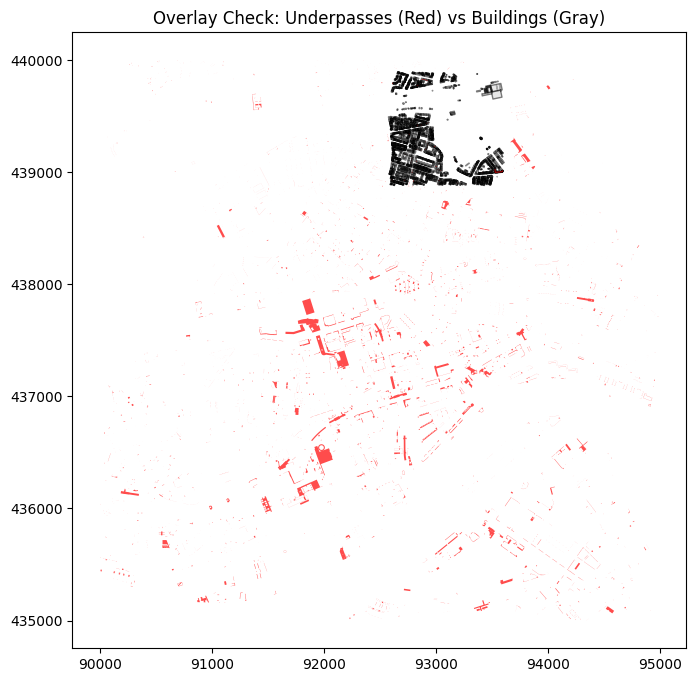

In [88]:
oblique_images_dir = os.path.join(PROJECT_ROOT, 'data/oblique_images')
image_footprints_path = os.path.join(oblique_images_dir, 'rotterdam_footprints_renamed.geojson')
underpasses_directory = os.path.join(PROJECT_ROOT, 'data/underpass_polygons')
underpasses_path = os.path.join(underpasses_directory, 'underpasses_rotterdam.geojson')
tiles_directory = os.path.join(PROJECT_ROOT, 'data/3dbag_tiles')
geojson_2d_path = os.path.join(tiles_directory, 'lod22_2d.geojson')
geojson_3d_path = os.path.join(tiles_directory, 'lod22_3d.geojson')

# def load_input_data(camera_parameters_path, image_footprints_path, underpasses_path, underpass_edges_path, ground_truth_path, min_length):
def load_input_data(camera_parameters_path, underpasses_path, geojson_2d_path, geojson_3d_path, image_footprints_path, min_length):
    """
    Load input data from specified paths and preprocess them into GeoDataFrames.

    Args:
        camera_parameters_path (str): Path to the camera parameters file.
        image_footprints_path (str): Path to the image footprints file.
        underpasses_path (str): Path to the underpass polygons file.
        underpass_edges_path (str): Path to the underpass edges file (optional, can be None).
        min_length (float): Minimum length of edges to be considered as critical.

    Returns:
        tuple: A tuple containing the following GeoDataFrames:
            - df_camera_parameters (GeoDataFrame): GeoDataFrame containing camera parameters.
            - gdf_image_footprints (GeoDataFrame): GeoDataFrame containing image footprints.
            - gdf_underpass_polygons (GeoDataFrame): GeoDataFrame containing underpass polygons.
            - gdf_underpass_edges (GeoDataFrame or None): GeoDataFrame containing underpass edges if provided, otherwise None.

    """
    # 1. Load camera parameters (use comma separator and strip space from columns)
    df_camera_parameters = pd.read_csv(camera_parameters_path, sep=',', dtype={'image_id': str})
    df_camera_parameters.columns = df_camera_parameters.columns.str.strip()

    gdf_underpass_polygons = gpd.read_file(underpasses_path)
    gdf_underpass_polygons = gdf_underpass_polygons.set_crs("EPSG:7415", allow_override=True)
    gdf_underpass_polygons = gdf_underpass_polygons.rename(columns={'identificatie': 'building_id'})
    gdf_underpass_polygons['underpass_id'] = gdf_underpass_polygons.index + 1

    gdf_image_footprints = gpd.read_file(image_footprints_path)
    gdf_image_footprints = gdf_image_footprints.set_crs("EPSG:7415", allow_override=True)
    gdf_image_footprints.columns = gdf_image_footprints.columns.str.strip()

    # merge for ading camera center per footprint
    # gdf_image_footprints = gdf_image_footprints.merge(df_camera_parameters, left_on='image_id', right_on='image_id', how='left')
    gdf_image_footprints = gdf_image_footprints[['image_id', 'geometry', 'X', 'Y', 'Z']].rename(columns={'X': 'camera_x', 'Y': 'camera_y', 'Z': 'camera_z'})

    # load 2d and 3d tiles
    gdf_building_2d = gpd.read_file(geojson_2d_path)
    gdf_building_2d = gdf_building_2d.rename(columns={'identificatie': 'building_id'})

    gdf_building_3d = gpd.read_file(geojson_3d_path)
    gdf_building_3d = gdf_building_3d.rename(columns={'identificatie': 'building_id'})


    # return df_camera_parameters, gdf_image_footprints, gdf_underpass_polygons, gdf_underpass_edges, gdf_ground_truth
    return df_camera_parameters, gdf_underpass_polygons, gdf_building_2d, gdf_building_3d, gdf_image_footprints


df_camera_parameters, gdf_underpass_polygons, gdf_building_2d, gdf_building_3d, gdf_image_footprints = (
    load_input_data(
        camera_parameters_path, underpasses_path, geojson_2d_path, geojson_3d_path, image_footprints_path, min_length=2
    )
)

# 1. Verify GeoDataFrames are loaded and not empty
print(f"Underpasses count: {len(gdf_underpass_polygons)}")
print(f"Buildings count:   {len(gdf_building_2d)}")

# 2. Check Column Names to see what ID fields actually exist
print("\n--- Underpasses Columns ---")
print(gdf_underpass_polygons.columns.tolist())

print("\n--- Buildings 2D Columns ---")
print(gdf_building_2d.columns.tolist())

# 3. Verify Coordinate Reference Systems (CRS) match
print("\n--- CRS Check ---")
print(f"Underpasses CRS: {gdf_underpass_polygons.crs}")
print(f"Buildings CRS:   {gdf_building_2d.crs}")

# 4. Check if the Spatial Join finds any spatial overlap
gdf_test_intersect = gpd.sjoin(
    gdf_underpass_polygons, 
    gdf_building_2d, 
    how="inner", 
    predicate="intersects"
)
print(f"\nSpatial Join Intersections Found: {len(gdf_test_intersect)}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
gdf_building_2d.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
gdf_underpass_polygons.plot(ax=ax, color='red', alpha=0.7)
plt.title("Overlay Check: Underpasses (Red) vs Buildings (Gray)")
plt.show()

In [95]:
from pathlib import Path
# Input paths
tiles_directory = os.path.join(PROJECT_ROOT, 'data/3dbag_tiles')
geojson_2d_path = os.path.join(tiles_directory, 'lod22_2d.geojson')
geojson_3d_path = os.path.join(tiles_directory, 'lod22_3d.geojson')

underpasses_directory = os.path.join(PROJECT_ROOT, 'data/underpass_polygons')
underpasses_path = os.path.join(underpasses_directory, 'underpasses_rotterdam.geojson')

oblique_images_dir = os.path.join(PROJECT_ROOT, 'data/oblique_images')
image_footprints_path = os.path.join(oblique_images_dir, 'rotterdam_footprints_renamed.geojson')
tile_footprint_path = os.path.join(oblique_images_dir, 'intersected_tile_footprint.geojson')
camera_parameters_path = os.path.join(PROJECT_ROOT, 'output/rotterdam_camera_parameters.csv')

# Output directory for all facades
facades_output_dir = Path(os.path.expanduser("~/Desktop")) / "extracted_facades"
facades_output_dir.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

# def load_input_data(camera_parameters_path, image_footprints_path, underpasses_path, underpass_edges_path, ground_truth_path, min_length):
def load_input_data(camera_parameters_path, underpasses_path, geojson_2d_path, geojson_3d_path, image_footprints_path, min_length):
    """
    Load input data from specified paths and preprocess them into GeoDataFrames.

    Args:
        camera_parameters_path (str): Path to the camera parameters file.
        image_footprints_path (str): Path to the image footprints file.
        underpasses_path (str): Path to the underpass polygons file.
        underpass_edges_path (str): Path to the underpass edges file (optional, can be None).
        min_length (float): Minimum length of edges to be considered as critical.

    Returns:
        tuple: A tuple containing the following GeoDataFrames:
            - df_camera_parameters (GeoDataFrame): GeoDataFrame containing camera parameters.
            - gdf_image_footprints (GeoDataFrame): GeoDataFrame containing image footprints.
            - gdf_underpass_polygons (GeoDataFrame): GeoDataFrame containing underpass polygons.
            - gdf_underpass_edges (GeoDataFrame or None): GeoDataFrame containing underpass edges if provided, otherwise None.

    """
    # 1. Load camera parameters (use comma separator and strip space from columns)
    df_camera_parameters = pd.read_csv(camera_parameters_path, sep=',', dtype={'image_id': str})
    df_camera_parameters.columns = df_camera_parameters.columns.str.strip()

    gdf_underpass_polygons = gpd.read_file(underpasses_path)
    gdf_underpass_polygons = gdf_underpass_polygons.set_crs("EPSG:7415", allow_override=True)
    gdf_underpass_polygons = gdf_underpass_polygons.rename(columns={'identificatie': 'building_id'})
    gdf_underpass_polygons['underpass_id'] = gdf_underpass_polygons.index + 1

    gdf_image_footprints = gpd.read_file(image_footprints_path)
    gdf_image_footprints = gdf_image_footprints.set_crs("EPSG:7415", allow_override=True)
    gdf_image_footprints.columns = gdf_image_footprints.columns.str.strip()

    # merge for ading camera center per footprint
    # gdf_image_footprints = gdf_image_footprints.merge(df_camera_parameters, left_on='image_id', right_on='image_id', how='left')
    gdf_image_footprints = gdf_image_footprints[['image_id', 'geometry', 'X', 'Y', 'Z']].rename(columns={'X': 'camera_x', 'Y': 'camera_y', 'Z': 'camera_z'})

    # load 2d and 3d tiles
    gdf_building_2d = gpd.read_file(geojson_2d_path)
    gdf_building_2d = gdf_building_2d.rename(columns={'identificatie': 'building_id'})

    gdf_building_3d = gpd.read_file(geojson_3d_path)
    gdf_building_3d = gdf_building_3d.rename(columns={'identificatie': 'building_id'})


    # return df_camera_parameters, gdf_image_footprints, gdf_underpass_polygons, gdf_underpass_edges, gdf_ground_truth
    return df_camera_parameters, gdf_underpass_polygons, gdf_building_2d, gdf_building_3d, gdf_image_footprints



In [96]:
def find_critical_edges(gdf_underpasses, gdf_footprints, buf_tol=1.0, simpl_tol=0.2, min_length=0.5):
    """
    Find critical edges of underpass polygons that intersect with building footprints.
    """
    # Ensure CRS matches
    gdf_footprints = gdf_footprints.to_crs(gdf_underpasses.crs)

    # Perform spatial join
    gdf_intersected = gpd.sjoin(
        gdf_underpasses,
        gdf_footprints,
        how="inner",
        predicate="intersects"
    )

    edge_records = []
    edge_id = 1

    for _, row in gdf_intersected.iterrows():
        underpass_id = row.get("underpass_id")
        
        # Pull the footprint ID generated by sjoin
        building_id = (
            row.get("building_id_right") or 
            row.get("b3_pand_deel_id") or 
            row.get("building_id_left") or 
            row.get("building_id")
        )

        if not building_id:
            continue

        # Match building geometry in gdf_footprints using building_id or b3_pand_deel_id
        matching_footprints = gdf_footprints.loc[
            (gdf_footprints.get("building_id") == building_id) | 
            (gdf_footprints.get("b3_pand_deel_id") == building_id), 
            "geometry"
        ]
        
        if matching_footprints.empty:
            continue
            
        building_geom = matching_footprints.iloc[0]
        buffered_boundary = building_geom.boundary.buffer(buf_tol)

        # Simplify underpass polygon geometry and extract boundary edges
        simplified_geom = row["geometry"].simplify(tolerance=simpl_tol, preserve_topology=True)
        
        # Handle both Polygon and MultiPolygon geometries
        if simplified_geom.geom_type == 'Polygon':
            polygons = [simplified_geom]
        elif simplified_geom.geom_type == 'MultiPolygon':
            polygons = list(simplified_geom.geoms)
        else:
            continue

        for poly in polygons:
            coords = list(poly.exterior.coords)
            for i in range(len(coords) - 1):
                edge = shapely.geometry.LineString([coords[i], coords[i + 1]])
                if edge.length >= min_length and edge.intersects(buffered_boundary):
                    edge_records.append({
                        "edge_id": edge_id,
                        "geometry": edge,
                        "underpass_id": underpass_id,
                        "building_id": building_id
                    })
                    edge_id += 1

    # Return valid GeoDataFrame with explicit geometry column defined
    if not edge_records:
        print("Warning: 0 critical edges matched buffer/length thresholds.")
        return gpd.GeoDataFrame(
            columns=["edge_id", "geometry", "underpass_id", "building_id"],
            crs=gdf_underpasses.crs,
            geometry="geometry"
        )

    return gpd.GeoDataFrame(edge_records, crs=gdf_underpasses.crs, geometry="geometry")

def visualize_critical_edges(gdf_underpass_intersected, gdf_critical_edges):

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf_critical_edges.plot(
        ax=ax,
        color="red",
        linewidth=3
    )
    gdf_underpass_intersected.plot(
        ax=ax,
        color="gray",
        linewidth=1
    )

    ax.set_title("Critical Underpass Edges")
    ax.axis("off")
    ax.set_aspect("equal")
    plt.show()


def find_critical_walls(gdf_critical_edges, gdf_underpass_edges, gdf_building_3d, buf_tol, extend_length):

    """
    Find critical walls by extruding critical edges to 3D using the height of building 3D geometries. 
    If underpass edges are provided, use them to find the critical walls instead of critical edges.

    Args:
        gdf_critical_edges (GeoDataFrame): GeoDataFrame containing critical edges.
        gdf_underpass_edges (GeoDataFrame or None): GeoDataFrame containing underpass edges if provided, otherwise None.
        gdf_building_3d (GeoDataFrame): GeoDataFrame containing building 3D geometries with columns 'building_id' and 'geometry'.
        buf_tol (float): Buffer tolerance for the intersection of underpass edges with building 3D geometries.
        extend_length (float): Length to extend the walls on both sides of the edge.
    
    Returns:
        GeoDataFrame: A GeoDataFrame containing critical walls.

    """
    # Extract 3d wall polygons from buildings
    wall_polygon_records = []
    wall_polygon_id = 1
    for _, row in gdf_building_3d.iterrows():
        building_id = row['building_id']
        geom = row['geometry']
        if geom.geom_type == 'Polygon':
            wall_polygon_records.append({'wall_id': wall_polygon_id, 'geometry': geom, 'building_id': building_id})
            wall_polygon_id += 1
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                wall_polygon_records.append({'wall_id': wall_polygon_id, 'geometry': poly, 'building_id': building_id})
                wall_polygon_id += 1

    gdf_wall_polygons = gpd.GeoDataFrame(wall_polygon_records, crs=gdf_building_3d.crs)
    
    # Intersect 3d wall polygons with critical edges (buffered) or provided underpass edges
    if gdf_underpass_edges is not None:
        gdf_underpass_edges_buffered = gdf_underpass_edges.copy()
        gdf_underpass_edges_buffered['geometry'] = gdf_underpass_edges_buffered.geometry.buffer(buf_tol)

        gdf_underpass_edges_buffered = gdf_underpass_edges_buffered.to_crs(gdf_wall_polygons.crs)
        gdf_walls_intersected = gpd.sjoin(gdf_wall_polygons, gdf_underpass_edges_buffered, how='inner', predicate='intersects')
        # Make sure that the extracted 3D polygons belong to the same building as the underpass edge
        gdf_walls_intersected = gdf_walls_intersected[
            gdf_walls_intersected['building_id_left'] == gdf_walls_intersected['building_id_right']
        ]
        gdf_walls_intersected = gdf_walls_intersected[
            ['wall_id', 'geometry', 'edge_id', 'building_id_right', 'underpass_id']
        ].rename(columns={'building_id_right': 'building_id'})
    
    else:
        gdf_critical_edges_buffered = gdf_critical_edges.copy()
        gdf_critical_edges_buffered['geometry'] = gdf_critical_edges_buffered.geometry.buffer(buf_tol)

        gdf_critical_edges_buffered = gdf_critical_edges_buffered.to_crs(gdf_wall_polygons.crs)
        gdf_walls_intersected = gpd.sjoin(gdf_wall_polygons, gdf_critical_edges_buffered, how='inner', predicate='intersects')

        # Make sure that the extracted 3D polygons belong to the same building as the underpass edge
        gdf_walls_intersected = gdf_walls_intersected[
            gdf_walls_intersected['building_id_left'] == gdf_walls_intersected['building_id_right']
        ]
        gdf_walls_intersected = gdf_walls_intersected[
            ['wall_id', 'geometry', 'edge_id', 'building_id_right', 'underpass_id']
        ].rename(columns={'building_id_right': 'building_id'})

    # Create walls using the height of wall polygons and the edges
    wall_records = []
    wall_id = 1
    for edge_id, group in gdf_walls_intersected.groupby('edge_id'):
        # Find the maximum and minimum height of the wall polygons which belong to an edge
        max_z = -float('inf')
        min_z = float('inf')
        for geom in group['geometry']:
            for x, y, z in geom.exterior.coords:
                if z > max_z:
                    max_z = z
                elif z < min_z:
                    min_z = z
        # Find the geometry of the edge (depending on provided table)
        if gdf_underpass_edges is not None:
            edge_geom = gdf_underpass_edges[gdf_underpass_edges['edge_id'] == edge_id]['geometry'].iloc[0]
        else:
            edge_geom = gdf_critical_edges[gdf_critical_edges['edge_id'] == edge_id]['geometry'].iloc[0]
        # bottom2d = list(edge_geom.coords)
        p1 = np.array(edge_geom.coords[0])
        p2 = np.array(edge_geom.coords[1])
        direction = p2 - p1
        length = np.linalg.norm(direction)
        if length == 0:
            continue
        direction_unit = direction / length
        # Extend walls on both sides (create wider walls)
        new_p1 = p1 - direction_unit * extend_length
        new_p2 = p2 + direction_unit * extend_length
        bottom2d = [tuple(new_p1), tuple(new_p2)]

        bottom3d = [(x, y, min_z) for x, y, *_ in bottom2d]
        upper3d = [(x, y, max_z) for x, y, *_  in reversed(bottom2d)]

        wall_coords = bottom3d + upper3d
        
        # Build the wall geometry
        wall_geom = shapely.geometry.polygon.orient(Polygon(wall_coords), sign=1.0)
        # Build wall records
        underpass_id = group['underpass_id'].iloc[0]
        wall_records.append({
            'wall_id': wall_id,
            'geometry': wall_geom,
            'wall_height': max_z - min_z,
            'underpass_id': underpass_id,
            'edge_id': edge_id,
            'building_id': group['building_id'].iloc[0]
        })
        wall_id += 1

    gdf_critical_walls = gpd.GeoDataFrame(wall_records, crs=gdf_wall_polygons.crs)

    # If there are two overlapping walls or they are too close, keep the largest wall
    walls_to_remove = set()
    for i in range(len(gdf_critical_walls)):
        if i in walls_to_remove:
            continue
        geom_i = gdf_critical_walls.iloc[i]['geometry']
        area_i = geom_i.area
        for j in range(i + 1, len(gdf_critical_walls)):
            if j in walls_to_remove:
                continue
            geom_j = gdf_critical_walls.iloc[j]['geometry']
            # Check if walls overlap
            if  geom_i.within(geom_j) or geom_j.within(geom_i):
                area_j = geom_j.area
                # Keep the larger one, mark the smaller for removal
                if area_i > area_j:
                    walls_to_remove.add(j)
                else:
                    walls_to_remove.add(i)
                    break
    
    # Remove marked walls and reset indices
    gdf_critical_walls = gdf_critical_walls.drop(list(walls_to_remove)).reset_index(drop=True)

    return gdf_critical_walls


gdf_critical_edges = find_critical_edges(
    gdf_underpass_polygons, gdf_building_2d, buf_tol=0.1, simpl_tol=0.2, min_length=2
)

gdf_critical_walls = find_critical_walls(
    gdf_critical_edges, None, gdf_building_3d, buf_tol=0.5, extend_length=0
)

print(f"Total critical edges: {len(gdf_critical_edges)}")
print(f"Total critical walls generated: {len(gdf_critical_walls)}")

Total critical edges: 284
Total critical walls generated: 117


In [85]:
print(df_camera_csv["omega"].head(5))
print(df_camera_csv["phi"].head(5))
print(df_camera_csv["kappa"].head(5))

0    23.107387
1     2.990840
2    -5.483206
3    57.605173
4     4.847223
Name: omega, dtype: float64
0    44.417198
1    45.103401
2    45.153702
3    43.948299
4    45.155399
Name: phi, dtype: float64
0   -15.962604
1   -17.521049
2   -15.876661
3   -10.783066
4   -18.913337
Name: kappa, dtype: float64


In [84]:

# Juan footprints
PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"
juan_camera_para = os.path.join(PROJECT_ROOT, "data/oblique_images/camera_parameters.txt")
juan_footprint = os.path.join(PROJECT_ROOT, "data/oblique_images/image_footprints.geojson")
df_juan_camera_para = pd.read_csv(juan_camera_para, sep='\t', dtype={'image_id': str})
gdf_juan_footprints = gpd.read_file(juan_footprint)
df_juan_camera_para.columns = df_juan_camera_para.columns.str.strip()
#print(df_juan_camera_para.head(10))
#print(gdf_juan_footprints.head(10))
print(df_juan_camera_para["omega"].head(5))
print(df_juan_camera_para["phi"].head(5))
print(df_juan_camera_para["kappa"].head(5))

0    12.13
1    12.51
2    12.56
3    15.22
4    11.38
Name: omega, dtype: float64
0    43.97
1    43.71
2    43.44
3   -41.53
4    44.05
Name: phi, dtype: float64
0    107.63
1    107.11
2    107.51
3   -112.82
4    105.87
Name: kappa, dtype: float64


In [98]:
import numpy as np
import pandas as pd
import geopandas as gpd

print("=== STAGE 1: Critical Edges Check ===")
print(f"Total critical edges generated: {len(gdf_critical_edges)}")
if len(gdf_critical_edges) == 0:
    print("❌ STOP: 0 critical edges found. Check spatial join and buffer tolerances.")

print("\n=== STAGE 2: Critical 3D Walls Check ===")
print(f"Total critical walls generated: {len(gdf_critical_walls)}")
if not gdf_critical_walls.empty:
    print("Wall Height Stats:")
    print(f"  - Min height: {gdf_critical_walls['wall_height'].min():.2f}m")
    print(f"  - Max height: {gdf_critical_walls['wall_height'].max():.2f}m")
    print(f"  - Mean height: {gdf_critical_walls['wall_height'].mean():.2f}m")
    
    # Check for zero or NaN height walls
    invalid_heights = gdf_critical_walls[gdf_critical_walls['wall_height'] <= 0]
    print(f"  - Walls with height <= 0: {len(invalid_heights)}")

print("\n=== STAGE 3: Spatial Join with Image Footprints ===")
gdf_image_footprints = gdf_image_footprints.to_crs(gdf_critical_walls.crs)
sjoin_raw = gpd.sjoin(gdf_image_footprints, gdf_critical_walls, how='inner', predicate='intersects')
print(f"Raw image footprint & wall candidate pairs found: {len(sjoin_raw)}")
print(f"Unique images intersecting walls: {sjoin_raw['image_id'].nunique()}")
print(f"Unique walls intersecting image footprints: {sjoin_raw['wall_id'].nunique()}")

print("\n=== STAGE 4: Vector Angle & Visibility Math Debugging ===")
theta = 60.0  # Angle threshold in degrees

# Track reasons for rejection in the vector loop
total_evaluated = 0
passed_visibility = 0
dropped_normal_facing = 0
dropped_steep_angle = 0

# Sample audit on all candidate pairs
grouped = sjoin_raw.groupby('image_id')

for image_id, group in grouped:
    cam_pos = np.array([group['camera_x'].iloc[0], group['camera_y'].iloc[0], group['camera_z'].iloc[0]], dtype=float)
    
    for wall_id in group['wall_id'].unique():
        total_evaluated += 1
        wall_row = gdf_critical_walls[gdf_critical_walls['wall_id'] == wall_id].iloc[0]
        coords = np.array(wall_row['geometry'].exterior.coords)

        # 1. Edge vectors
        v_horiz = coords[1] - coords[0]
        v_vert = coords[3] - coords[0]

        # 2. Wall normal
        wall_normal = np.cross(v_horiz, v_vert)
        norm_val = np.linalg.norm(wall_normal)
        if norm_val == 0:
            continue
        wall_normal = wall_normal / norm_val

        # 3. Ray from wall center to camera
        wall_center = np.mean(coords[:4], axis=0)
        v_to_camera = cam_pos - wall_center
        v_dist = np.linalg.norm(v_to_camera)
        if v_dist == 0:
            continue
        v_to_camera = v_to_camera / v_dist

        # 4. Angle calculation
        dot_product = np.dot(wall_normal, v_to_camera)
        angle_deg = np.degrees(np.arccos(np.clip(abs(dot_product), 0.0, 1.0)))

        # Evaluate filter conditions
        if dot_product < 0:
            dropped_normal_facing += 1
        
        if angle_deg >= theta:
            dropped_steep_angle += 1
        else:
            passed_visibility += 1

print("--- Diagnostics Summary ---")
print(f"Total Wall-Image pairs evaluated: {total_evaluated}")
print(f"✅ Pairs passing visibility check (angle < {theta}°): {passed_visibility}")
print(f"❌ Pairs flagged as facing away (dot_product < 0): {dropped_normal_facing}")
print(f"❌ Pairs dropped due to steep angle (angle >= {theta}°): {dropped_steep_angle}")

=== STAGE 1: Critical Edges Check ===
Total critical edges generated: 284

=== STAGE 2: Critical 3D Walls Check ===
Total critical walls generated: 117
Wall Height Stats:
  - Min height: 6.15m
  - Max height: 17.84m
  - Mean height: 12.19m
  - Walls with height <= 0: 0

=== STAGE 3: Spatial Join with Image Footprints ===
Raw image footprint & wall candidate pairs found: 1869
Unique images intersecting walls: 76
Unique walls intersecting image footprints: 117

=== STAGE 4: Vector Angle & Visibility Math Debugging ===
--- Diagnostics Summary ---
Total Wall-Image pairs evaluated: 1869
✅ Pairs passing visibility check (angle < 60.0°): 903
❌ Pairs flagged as facing away (dot_product < 0): 948
❌ Pairs dropped due to steep angle (angle >= 60.0°): 966


In [100]:
import os
import cv2
def load_oblique_image(image_identifier, directories):
    """
    Attempts to load an oblique image from a list of directory paths.
    
    :param image_identifier: String or int representing the image filename/ID.
    :param directories: List of directory paths or single directory string.
    :return: Loaded image array or None if not found.
    """
    if isinstance(directories, str):
        directories = [directories]

    image_str = str(image_identifier).strip()

    # Ensure extension exists
    possible_names = [image_str]
    if not image_str.lower().endswith(('.jpg', '.jpeg', '.tif', '.tiff', '.png')):
        possible_names.append(f"{image_str}.jpg")
        possible_names.append(f"{image_str}.png")

    # Search through all provided directory subfolders
    for directory in directories:
        for name in possible_names:
            full_path = os.path.join(directory, name)
            if os.path.exists(full_path):
                img = cv2.imread(full_path)
                if img is not None:
                    return img

    return None
# 1. Filter STAGE 3 pairs using the passing visibility condition
valid_pairs = []
for image_id, group in sjoin_raw.groupby('image_id'):
    cam_pos = np.array([group['camera_x'].iloc[0], group['camera_y'].iloc[0], group['camera_z'].iloc[0]], dtype=float)
    for wall_id in group['wall_id'].unique():
        wall_row = gdf_critical_walls[gdf_critical_walls['wall_id'] == wall_id].iloc[0]
        coords = np.array(wall_row['geometry'].exterior.coords)
        
        v_horiz = coords[1] - coords[0]
        v_vert = coords[3] - coords[0]
        wall_normal = np.cross(v_horiz, v_vert)
        norm_val = np.linalg.norm(wall_normal)
        if norm_val == 0: continue
        wall_normal /= norm_val
        
        wall_center = np.mean(coords[:4], axis=0)
        v_to_camera = cam_pos - wall_center
        v_dist = np.linalg.norm(v_to_camera)
        if v_dist == 0: continue
        v_to_camera /= v_dist
        
        dot_product = np.dot(wall_normal, v_to_camera)
        angle_deg = np.degrees(np.arccos(np.clip(abs(dot_product), 0.0, 1.0)))
        
        if angle_deg < 60.0:
            valid_pairs.append({'image_id': image_id, 'wall_id': wall_id})

df_valid_pairs = pd.DataFrame(valid_pairs)
print(f"Candidate pairs passed to image loading/projection stage: {len(df_valid_pairs)}")
print(f"Unique images to load: {df_valid_pairs['image_id'].nunique()}")

# 2. Check how many of these images actually exist on disk
image_dir = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights/data/oblique_images"  # Update path

loaded_count = 0
failed_images = []

for img_id in df_valid_pairs['image_id'].unique():
    img = load_oblique_image(img_id, [image_dir])
    if img is not None:
        loaded_count += 1
    else:
        failed_images.append(img_id)

print("\n--- Image Loading Diagnostic ---")
print(f"✅ Images successfully loaded: {loaded_count} / {df_valid_pairs['image_id'].nunique()}")
print(f"❌ Images failed to load: {len(failed_images)}")
if failed_images:
    print(f"Sample failed image ID: {failed_images[0]}")

Candidate pairs passed to image loading/projection stage: 903
Unique images to load: 75

--- Image Loading Diagnostic ---
✅ Images successfully loaded: 0 / 75
❌ Images failed to load: 75
Sample failed image ID: 178001098_0036_01_0175_P00_01.jpg


In [101]:
import os

# Search root directory for the sample image
search_root = "/Users/belinaileen/Desktop/aileen_underpass-detection"
sample_filename = "178001098_0036_01_0175_P00_01.jpg"

found_paths = []
for root, dirs, files in os.walk(search_root):
    if sample_filename in files:
        found_paths.append(os.path.join(root, sample_filename))

print("=== IMAGE SEARCH RESULTS ===")
if found_paths:
    print(f"✅ Found sample image at:\n{found_paths[0]}")
    print(f"\nExact folder to pass as image_dir:\n{os.path.dirname(found_paths[0])}")
else:
    print(f"❌ Sample image '{sample_filename}' was NOT found anywhere inside '{search_root}'.")

=== IMAGE SEARCH RESULTS ===
✅ Found sample image at:
/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights/rotterdam_sample/oblique_forward/178001098_0036_01_0175_P00_01.jpg

Exact folder to pass as image_dir:
/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights/rotterdam_sample/oblique_forward


In [55]:
'''
check if rotterdam footprint and camera parameters linkage is correct
'''

PROJECT_ROOT = "/Users/belinaileen/Desktop/aileen_underpass-detection/3DBAG_underpass_heights"

camera_parameters_path = os.path.join(
    PROJECT_ROOT,
    "output/rotterdam_camera_parameters.csv")

footprints_path = os.path.join(
    PROJECT_ROOT,
    "data/oblique_images/rotterdam_footprints_renamed.geojson"
)

images_directory = os.path.join(
    PROJECT_ROOT,
    "data/oblique_images")

camera = pd.read_csv(
    camera_parameters_path,
    sep=",",
    dtype={"image_id": str})

footprints = gpd.read_file(footprints_path)

# Clean column names
camera.columns = camera.columns.str.strip()
footprints.columns = footprints.columns.str.strip()

# Make image IDs strings
camera["image_id"] = camera["image_id"].astype(str).str.strip()
footprints["image_id"] = footprints["image_id"].astype(str).str.strip()

print("Camera parameters:")
print(camera.shape)
print(camera.columns.tolist())

print("\nImage footprints:")
print(footprints.shape)
print(footprints.columns.tolist())

print("Number of camera parameter rows:", len(camera))
print("Number of footprint rows:", len(footprints))

print("\nUnique camera image IDs:", camera["image_id"].nunique())
print("Unique footprint image IDs:", footprints["image_id"].nunique())

print("\nFirst 10 camera IDs:")
print(camera["image_id"].head(10).tolist())

print("\nFirst 10 footprint IDs:")
print(footprints["image_id"].head(10).tolist())

camera_ids = set(camera["image_id"])
footprint_ids = set(footprints["image_id"])

camera_not_in_footprints = camera_ids - footprint_ids
footprints_not_in_camera = footprint_ids - camera_ids

print("Camera IDs:", len(camera_ids))
print("Footprint IDs:", len(footprint_ids))

print("\nCamera IDs WITHOUT a matching footprint:")
print(len(camera_not_in_footprints))
print(list(camera_not_in_footprints)[:20])

print("\nFootprint IDs WITHOUT a matching camera parameter:")
print(len(footprints_not_in_camera))
print(list(footprints_not_in_camera)[:20])

Camera parameters:
(16245, 13)
['image_id', 'width', 'height', 'fx', 'fy', 'cx', 'cy', 'X', 'Y', 'Z', 'omega', 'phi', 'kappa']

Image footprints:
(16245, 86)
['id', 'ULx', 'ULy', 'URx', 'URy', 'LLx', 'LLy', 'LRx', 'LRy', 'GSD', 'ShotOrient', 'Inpho_11', 'Inpho_12', 'Inpho_13', 'Inpho_21', 'Inpho_22', 'Inpho_23', 'Inpho_31', 'Inpho_32', 'Inpho_33', 'Matrix_11', 'Matrix_12', 'Matrix_13', 'Matrix_21', 'Matrix_22', 'Matrix_23', 'Matrix_31', 'Matrix_32', 'Matrix_33', 'CAM', 'Collection Input', 'image_id', 'Mean median error Calculated', 'Focal Length Calculated', 'fx', 'Pixel Size Input', 'Median Error Calculated', 'PPoint X Calculated', 'cx', 'PPoint Y Calculated', 'cy', 'K1 Calculated', 'K1 Input', 'K2 Calculated', 'K2 Input', 'K3 Calculated', 'K3 Input', 'P1 Calculated', 'P1 Input', 'P2 Calculated', 'P2 Input', 'X Calculated', 'X', 'Y Calculated', 'Y', 'Altitude Calculated', 'Z', 'Omega Calculated', 'omega', 'Phi Calculated', 'phi', 'Kappa Calculated', 'kappa', 'Yaw Calculated', 'Yaw Inp